# E-Commerce Sales & Customer Analytics

## Data Profiling

This notebook performs the initial inspection and profiling of the
Superstore e-commerce dataset before data cleaning and analysis.


In [1]:
import pandas as pd

In [2]:
file_path = r"C:\Users\mrluc\ecommerce-analytics\data\raw\superstore.csv.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 1. Dataset Overview

Before cleaning or transforming the data, we will examine its structure,
dimensions, data types, missing values, duplicates, and basic statistics.

In [3]:
df.shape

(9994, 21)

In [4]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

## 2. Data Validation

We now validate key categorical, date, and numerical fields to understand
their ranges and identify values that may require transformation.

In [10]:
print("Order Date range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nShip Date range:")
print(df["Ship Date"].min(), "to", df["Ship Date"].max())

Order Date range:
1/1/2017 to 9/9/2017

Ship Date range:
1/1/2015 to 9/9/2017


In [11]:
df["Category"].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

In [12]:
df["Sub-Category"].nunique()

17

In [13]:
df["Region"].unique()

<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

In [14]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [15]:
negative_profit = df[df["Profit"] < 0]

print("Loss-making transactions:", len(negative_profit))

Loss-making transactions: 1871


In [16]:
print("Total transaction records:", len(df))
print("Unique orders:", df["Order ID"].nunique())
print("Unique customers:", df["Customer ID"].nunique())
print("Unique products:", df["Product ID"].nunique())

Total transaction records: 9994
Unique orders: 5009
Unique customers: 793
Unique products: 1862


In [17]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    str
Ship Date     str
dtype: object

In [18]:
df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,11/8/2016,11/11/2016
1,11/8/2016,11/11/2016
2,6/12/2016,6/16/2016
3,10/11/2015,10/18/2015
4,10/11/2015,10/18/2015
5,6/9/2014,6/14/2014
6,6/9/2014,6/14/2014
7,6/9/2014,6/14/2014
8,6/9/2014,6/14/2014
9,6/9/2014,6/14/2014


In [19]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [20]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [21]:
print("Order Date range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nShip Date range:")
print(df["Ship Date"].min(), "to", df["Ship Date"].max())

Order Date range:
2014-01-03 00:00:00 to 2017-12-30 00:00:00

Ship Date range:
2014-01-07 00:00:00 to 2018-01-05 00:00:00


In [22]:
invalid_ship_dates = df[df["Ship Date"] < df["Order Date"]]

print("Orders shipped before order date:", len(invalid_ship_dates))

Orders shipped before order date: 0


In [23]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [24]:
df["Shipping Days"].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [25]:
print("Negative shipping durations:", (df["Shipping Days"] < 0).sum())

Negative shipping durations: 0


In [26]:
df["Shipping Days"].value_counts().sort_index()

Shipping Days
0     519
1     369
2    1334
3    1005
4    2774
5    2169
6    1203
7     621
Name: count, dtype: int64

In [27]:
categorical_columns = [
    "Segment",
    "Ship Mode",
    "Category",
    "Sub-Category",
    "Region"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


Segment:
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

Ship Mode:
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

Category:
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Sub-Category:
Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

Region:
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64


In [28]:
for column in categorical_columns:
    whitespace_values = df[column].astype(str).str.contains(
        r"^\s|\s$", regex=True
    ).sum()
    
    print(f"{column}: {whitespace_values} values with leading/trailing whitespace")

Segment: 0 values with leading/trailing whitespace
Ship Mode: 0 values with leading/trailing whitespace
Category: 0 values with leading/trailing whitespace
Sub-Category: 0 values with leading/trailing whitespace
Region: 0 values with leading/trailing whitespace


In [29]:
numeric_columns = ["Sales", "Quantity", "Discount", "Profit"]

for column in numeric_columns:
    print(
        f"{column}: "
        f"negative = {(df[column] < 0).sum()}, "
        f"zero = {(df[column] == 0).sum()}"
    )

Sales: negative = 0, zero = 0
Quantity: negative = 0, zero = 0
Discount: negative = 0, zero = 4798
Profit: negative = 1871, zero = 65


In [30]:
df.nlargest(10, "Sales")[
    ["Order ID", "Customer Name", "Product Name", "Sales", "Discount", "Profit"]
]

,Order ID,Customer Name,Product Name,Sales,Discount,Profit
2697,CA-2014-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,22638.480,0.5,-1811.0784
6826,CA-2016-118689,Tamara Chand,Canon imageCLASS 2200 Advanced Copier,17499.950,0.0,8399.9760
8153,CA-2017-140151,Raymond Buch,Canon imageCLASS 2200 Advanced Copier,13999.960,0.0,6719.9808
2623,CA-2017-127180,Tom Ashbrook,Canon imageCLASS 2200 Advanced Copier,11199.968,0.2,3919.9888
4190,CA-2017-166709,Hunter Lopez,Canon imageCLASS 2200 Advanced Copier,10499.970,0.0,5039.9856
9039,CA-2016-117121,Adrian Barton,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,0.0,4946.3700
4098,CA-2014-116904,Sanjit Chand,Ibico EPK-21 Electric Binding System,9449.950,0.0,4630.4755
4277,US-2016-107440,Bill Shonely,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,0.0,2365.9818
8488,CA-2016-158841,Sanjit Engle,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,0.0,2799.9840
6425,CA-2016-143714,Christopher Conant,Canon imageCLASS 2200 Advanced Copier,8399.976,0.4,1119.9968


In [31]:
df.nsmallest(10, "Profit")[
    ["Order ID", "Customer Name", "Product Name", "Sales", "Discount", "Profit"]
]

,Order ID,Customer Name,Product Name,Sales,Discount,Profit
7772,CA-2016-108196,Cindy Stewart,Cubify CubeX 3D Printer Double Head Print,4499.985,0.7,-6599.9780
683,US-2017-168116,Grant Thornton,Cubify CubeX 3D Printer Triple Head Print,7999.980,0.5,-3839.9904
9774,CA-2014-169019,Luke Foster,GBC DocuBind P400 Electric Binding System,2177.584,0.8,-3701.8928
3011,CA-2017-134845,Sharelle Roach,Lexmark MX611dhe Monochrome Laser Printer,2549.985,0.7,-3399.9800
4991,US-2017-122714,Henry Goldwyn,Ibico EPK-21 Electric Binding System,1889.990,0.8,-2929.4845
3151,CA-2015-147830,Natalie Fritzler,Cubify CubeX 3D Printer Double Head Print,1799.994,0.7,-2639.9912
5310,CA-2017-131254,Nathan Cano,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,0.8,-2287.7820
9639,CA-2015-116638,Joseph Holt,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,0.4,-1862.3124
1199,CA-2016-130946,Zuschuss Carroll,GBC DocuBind P400 Electric Binding System,1088.792,0.8,-1850.9464
2697,CA-2014-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,22638.480,0.5,-1811.0784


In [32]:
df.nlargest(10, "Profit")[
    ["Order ID", "Customer Name", "Product Name", "Sales", "Discount", "Profit"]
]

,Order ID,Customer Name,Product Name,Sales,Discount,Profit
6826,CA-2016-118689,Tamara Chand,Canon imageCLASS 2200 Advanced Copier,17499.950,0.0,8399.9760
8153,CA-2017-140151,Raymond Buch,Canon imageCLASS 2200 Advanced Copier,13999.960,0.0,6719.9808
4190,CA-2017-166709,Hunter Lopez,Canon imageCLASS 2200 Advanced Copier,10499.970,0.0,5039.9856
9039,CA-2016-117121,Adrian Barton,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,0.0,4946.3700
4098,CA-2014-116904,Sanjit Chand,Ibico EPK-21 Electric Binding System,9449.950,0.0,4630.4755
2623,CA-2017-127180,Tom Ashbrook,Canon imageCLASS 2200 Advanced Copier,11199.968,0.2,3919.9888
509,CA-2015-145352,Christopher Martinez,Fellowes PB500 Electric Punch Plastic Comb Bin...,6354.950,0.0,3177.4750
8488,CA-2016-158841,Sanjit Engle,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,0.0,2799.9840
7666,US-2016-140158,Daniel Raglin,Hewlett Packard LaserJet 3310 Copier,5399.910,0.0,2591.9568
6520,CA-2017-138289,Andy Reiter,GBC DocuBind P400 Electric Binding System,5443.960,0.0,2504.2216


## 3. Data Cleaning

The profiling stage identified date-format inconsistencies as the primary
data-type issue. Date fields were converted to datetime format.

No missing values, duplicate records, or invalid negative values were found
in the Sales, Quantity, or Discount fields. Negative Profit values are
retained because they represent legitimate loss-making transactions.

In [33]:
df_clean = df.copy()

print("Clean dataset created.")
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

Clean dataset created.
Rows: 9994
Columns: 22


In [34]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [35]:
df_clean.isnull().sum().sum()


np.int64(0)

In [36]:
df_clean.duplicated().sum()

np.int64(0)

In [37]:
df_clean.to_csv("../data/processed/superstore_clean.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 4. Exploratory Data Analysis

### 4.1 Overall Business Performance

We begin by calculating the key performance indicators for the dataset:
total sales, total profit, total quantity sold, number of orders,
number of customers, and overall profit margin.

In [38]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_quantity = df_clean["Quantity"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()

profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Quantity Sold: 37,873
Total Orders: 5,009
Total Customers: 793
Profit Margin: 12.47%


In [39]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Quantity",
        "Total Orders",
        "Total Customers",
        "Profit Margin"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_quantity,
        total_orders,
        total_customers,
        profit_margin
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Quantity,3.787300e+04
3,Total Orders,5.009000e+03
4,Total Customers,7.930000e+02
5,Profit Margin,1.246722e+01


### 4.2 Sales and Profit Trends

We analyze yearly sales and profit to understand overall business
performance and identify changes over time.

In [40]:
yearly_performance = (
    df_clean
    .groupby(df_clean["Order Date"].dt.year)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
    .rename(columns={"Order Date": "Year"})
)

yearly_performance

,Year,Sales,Profit,Orders
0,2014,484247.4981,49543.9741,969
1,2015,470532.5090,61618.6037,1038
2,2016,609205.5980,81795.1743,1315
3,2017,733215.2552,93439.2696,1687


In [41]:
yearly_performance["Profit Margin %"] = (
    yearly_performance["Profit"] /
    yearly_performance["Sales"] * 100
)

yearly_performance

,Year,Sales,Profit,Orders,Profit Margin %
0,2014,484247.4981,49543.9741,969,10.231126
1,2015,470532.5090,61618.6037,1038,13.095504
2,2016,609205.5980,81795.1743,1315,13.426530
3,2017,733215.2552,93439.2696,1687,12.743771


In [42]:
yearly_performance

,Year,Sales,Profit,Orders,Profit Margin %
0,2014,484247.4981,49543.9741,969,10.231126
1,2015,470532.5090,61618.6037,1038,13.095504
2,2016,609205.5980,81795.1743,1315,13.426530
3,2017,733215.2552,93439.2696,1687,12.743771


In [43]:
yearly_performance.round(2)

,Year,Sales,Profit,Orders,Profit Margin %
0,2014,484247.50,49543.97,969,10.23
1,2015,470532.51,61618.60,1038,13.10
2,2016,609205.60,81795.17,1315,13.43
3,2017,733215.26,93439.27,1687,12.74


In [44]:
yearly_performance["Sales Growth %"] = (
    yearly_performance["Sales"]
    .pct_change()
    .mul(100)
)

yearly_performance.round(2)

,Year,Sales,Profit,Orders,Profit Margin %,Sales Growth %
0,2014,484247.50,49543.97,969,10.23,NaN
1,2015,470532.51,61618.60,1038,13.10,-2.83
2,2016,609205.60,81795.17,1315,13.43,29.47
3,2017,733215.26,93439.27,1687,12.74,20.36


In [45]:
yearly_performance.loc[
    yearly_performance["Profit"].idxmax()
]

Year                 2017.000000
Sales              733215.255200
Profit              93439.269600
Orders               1687.000000
Profit Margin %        12.743771
Sales Growth %         20.355962
Name: 3, dtype: float64

In [46]:
yearly_performance.loc[
    yearly_performance["Profit"].idxmin()
]

Year                 2014.000000
Sales              484247.498100
Profit              49543.974100
Orders                969.000000
Profit Margin %        10.231126
Sales Growth %               NaN
Name: 0, dtype: float64

### 4.3 Yearly Sales and Profit Trend

The following visualization compares annual sales and profit to identify
overall growth and changes in profitability over the analysis period.

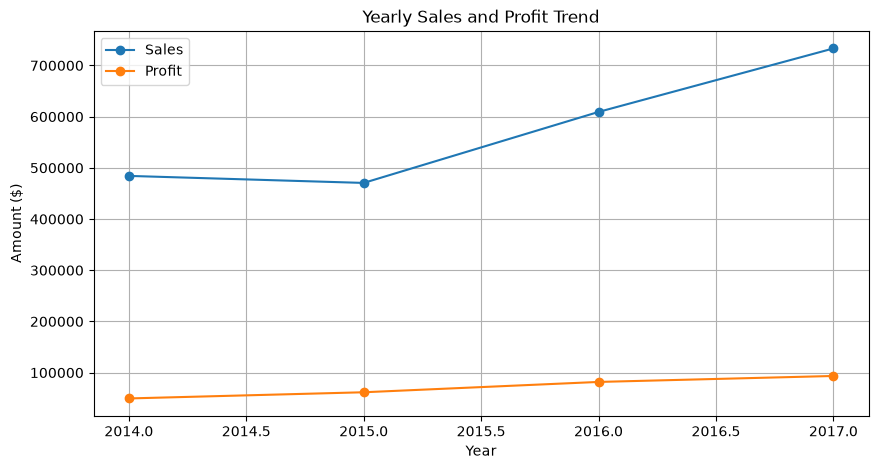

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_performance["Year"],
    yearly_performance["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    yearly_performance["Year"],
    yearly_performance["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Yearly Sales and Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount ($)")
plt.legend()
plt.grid(True)

plt.show()

In [48]:
monthly_performance = (
    df_clean
    .groupby(df_clean["Order Date"].dt.to_period("M"))
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

monthly_performance["Order Date"] = (
    monthly_performance["Order Date"].dt.to_timestamp()
)

monthly_performance.head()

,Order Date,Sales,Profit,Orders
0,2014-01-01,14236.895,2450.1907,32
1,2014-02-01,4519.892,862.3084,28
2,2014-03-01,55691.009,498.7299,71
3,2014-04-01,28295.345,3488.8352,66
4,2014-05-01,23648.287,2738.7096,69


In [49]:
monthly_performance.tail()

,Order Date,Sales,Profit,Orders
43,2017-08-01,63120.8880,9040.9557,111
44,2017-09-01,87866.6520,10991.5556,226
45,2017-10-01,77776.9232,9275.2755,147
46,2017-11-01,118447.8250,9690.1037,261
47,2017-12-01,83829.3188,8483.3468,224


In [50]:
monthly_performance.shape

(48, 4)

In [51]:
monthly_performance["Profit Margin %"] = (
    monthly_performance["Profit"] /
    monthly_performance["Sales"] * 100
)

monthly_performance[
    ["Sales", "Profit", "Orders", "Profit Margin %"]
].round(2)

,Sales,Profit,Orders,Profit Margin %
0,14236.90,2450.19,32,17.21
1,4519.89,862.31,28,19.08
2,55691.01,498.73,71,0.90
3,28295.34,3488.84,66,12.33
4,23648.29,2738.71,69,11.58
5,34595.13,4976.52,66,14.39
6,33946.39,-841.48,65,-2.48
7,27909.47,5318.10,72,19.05
8,81777.35,8328.10,130,10.18
9,31453.39,3448.26,78,10.96


In [52]:
monthly_performance[
    ["Sales", "Profit", "Orders", "Profit Margin %"]
].round(2)

,Sales,Profit,Orders,Profit Margin %
0,14236.90,2450.19,32,17.21
1,4519.89,862.31,28,19.08
2,55691.01,498.73,71,0.90
3,28295.34,3488.84,66,12.33
4,23648.29,2738.71,69,11.58
5,34595.13,4976.52,66,14.39
6,33946.39,-841.48,65,-2.48
7,27909.47,5318.10,72,19.05
8,81777.35,8328.10,130,10.18
9,31453.39,3448.26,78,10.96


In [53]:
best_profit_month = monthly_performance.loc[
    monthly_performance["Profit"].idxmax()
]

worst_profit_month = monthly_performance.loc[
    monthly_performance["Profit"].idxmin()
]

print("Best profit month:")
print(best_profit_month)

print("\nWorst profit month:")
print(worst_profit_month)

Best profit month:
Order Date         2016-12-01 00:00:00
Sales                        96999.043
Profit                      17885.3093
Orders                             176
Profit Margin %              18.438645
Name: 35, dtype: object

Worst profit month:
Order Date         2015-01-01 00:00:00
Sales                       18174.0756
Profit                       -3281.007
Orders                              29
Profit Margin %             -18.053226
Name: 12, dtype: object


In [54]:
highest_sales_month = monthly_performance.loc[
    monthly_performance["Sales"].idxmax()
]

print("Highest sales month:")
print(highest_sales_month)

Highest sales month:
Order Date         2017-11-01 00:00:00
Sales                       118447.825
Profit                       9690.1037
Orders                             261
Profit Margin %               8.180905
Name: 46, dtype: object


In [55]:
loss_months = monthly_performance[
    monthly_performance["Profit"] < 0
]

loss_months[
    ["Order Date", "Sales", "Profit", "Orders", "Profit Margin %"]
].style.format({
    "Sales": "{:.2f}",
    "Profit": "{:.2f}",
    "Profit Margin %": "{:.2f}"
})

,Order Date,Sales,Profit,Orders,Profit Margin %
6,2014-07-01 00:00:00,33946.39,-841.48,65,-2.48
12,2015-01-01 00:00:00,18174.08,-3281.01,29,-18.05


In [56]:
loss_transactions = df_clean[
    df_clean["Profit"] < 0
]

loss_transactions[
    [
        "Order Date",
        "Category",
        "Sub-Category",
        "Product Name",
        "Sales",
        "Discount",
        "Profit"
    ]
].sort_values("Profit")

,Order Date,Category,Sub-Category,Product Name,Sales,Discount,Profit
7772,2016-11-25,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,0.7,-6599.9780
683,2017-11-04,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,0.5,-3839.9904
9774,2014-07-26,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,0.8,-3701.8928
3011,2017-04-17,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,0.7,-3399.9800
4991,2017-12-07,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1889.990,0.8,-2929.4845
...,...,...,...,...,...,...,...
4660,2015-05-03,Technology,Accessories,SanDisk Cruzer 16 GB USB Flash Drive,27.552,0.2,-0.3444
7413,2017-05-30,Furniture,Furnishings,Tensor Brushed Steel Torchiere Floor Lamp,13.592,0.2,-0.3398
1566,2015-11-29,Technology,Accessories,Kingston Digital DataTraveler 16GB USB 2.0,21.480,0.2,-0.2685
1496,2017-09-04,Office Supplies,Storage,Acco Perma 3000 Stacking Storage Drawers,16.784,0.2,-0.2098


In [57]:
loss_transactions["Discount"].describe()

count    1871.000000
mean        0.480887
std         0.235080
min         0.100000
25%         0.200000
50%         0.400000
75%         0.700000
max         0.800000
Name: Discount, dtype: float64

In [58]:
df_clean["Discount"].describe()

count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64

In [59]:
loss_by_category = (
    loss_transactions
    .groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order ID", "count")
    )
    .reset_index()
)

loss_by_category["Profit Margin %"] = (
    loss_by_category["Profit"] /
    loss_by_category["Sales"] * 100
)

loss_by_category.round(2)

,Category,Sales,Profit,Transactions,Profit Margin %
0,Furniture,257885.59,-60936.11,714,-23.63
1,Office Supplies,91608.68,-56615.26,886,-61.80
2,Technology,119212.89,-38579.92,271,-32.36


In [60]:
loss_by_subcategory = (
    loss_transactions
    .groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order ID", "count"),
        Avg_Discount=("Discount", "mean")
    )
    .reset_index()
)

loss_by_subcategory["Profit Margin %"] = (
    loss_by_subcategory["Profit"] /
    loss_by_subcategory["Sales"] * 100
)

loss_by_subcategory.sort_values("Profit")

,Sub-Category,Sales,Profit,Transactions,Avg_Discount,Profit Margin %
2,Binders,36140.6130,-38510.4964,613,0.738010,-106.557397
11,Tables,104978.5460,-32412.1483,203,0.365271,-30.875021
7,Machines,72456.2530,-30118.6682,44,0.581818,-41.568073
3,Bookcases,48072.7408,-12152.2060,109,0.348532,-25.278788
4,Chairs,91988.4560,-9880.8413,235,0.261277,-10.741393
1,Appliances,3382.5340,-8629.6412,67,0.800000,-255.123561
8,Phones,35797.8400,-7530.6235,136,0.342647,-21.036530
6,Furnishings,12845.8440,-6490.9134,167,0.530539,-50.529287
9,Storage,37869.0720,-6426.3038,161,0.200000,-16.969795
10,Supplies,14067.1760,-3015.6219,33,0.200000,-21.437294


In [61]:
discount_profit = (
    df_clean
    .groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order ID", "count")
    )
    .reset_index()
)

discount_profit["Profit Margin %"] = (
    discount_profit["Profit"] /
    discount_profit["Sales"] * 100
)

discount_profit.round(2)

,Discount,Sales,Profit,Transactions,Profit Margin %
0,0.00,1087908.47,320987.60,4798,29.51
1,0.10,54369.35,9029.18,94,16.61
2,0.15,27558.52,1418.99,52,5.15
3,0.20,764594.37,90337.31,3657,11.82
4,0.30,103226.66,-10369.28,227,-10.05
5,0.32,14493.46,-2391.14,27,-16.50
6,0.40,116417.78,-23057.05,206,-19.81
7,0.45,5484.97,-2493.11,11,-45.45
8,0.50,58918.54,-20506.43,66,-34.80
9,0.60,6644.70,-5944.66,138,-89.46


In [62]:
discount_profit.sort_values("Discount")

,Discount,Sales,Profit,Transactions,Profit Margin %
0,0.00,1.087908e+06,320987.6032,4798,29.505019
1,0.10,5.436935e+04,9029.1770,94,16.607108
2,0.15,2.755852e+04,1418.9915,52,5.149012
3,0.20,7.645944e+05,90337.3060,3657,11.815063
4,0.30,1.032267e+05,-10369.2774,227,-10.045155
5,0.32,1.449346e+04,-2391.1377,27,-16.498047
6,0.40,1.164178e+05,-23057.0504,206,-19.805437
7,0.45,5.484974e+03,-2493.1111,11,-45.453472
8,0.50,5.891854e+04,-20506.4281,66,-34.804712
9,0.60,6.644700e+03,-5944.6552,138,-89.464614


### 4.4 Discount vs. Profitability

We examine the relationship between discount levels and profitability.
The analysis shows that profitability declines substantially as discount
levels increase, with discounts of 30% or higher producing negative
aggregate profit.

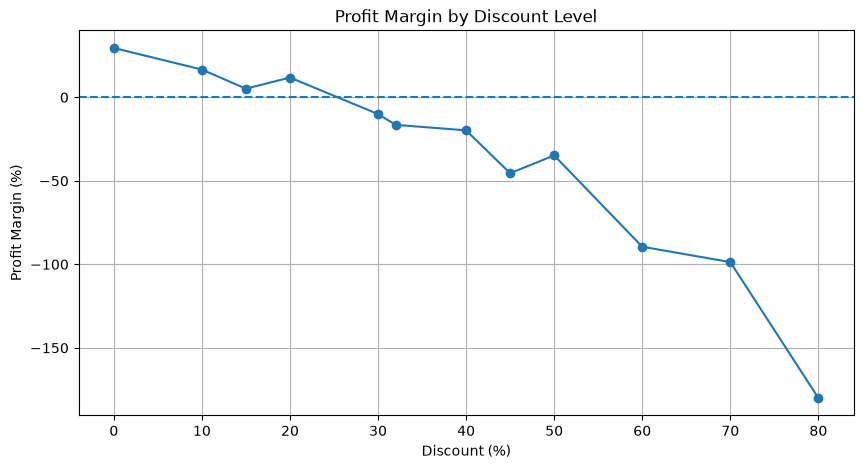

In [63]:
plt.figure(figsize=(10, 5))

plt.plot(
    discount_profit["Discount"] * 100,
    discount_profit["Profit Margin %"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Profit Margin by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.grid(True)

plt.show()

In [64]:
high_discount = df_clean[df_clean["Discount"] >= 0.30]

print("High-discount transactions:", len(high_discount))
print("High-discount sales:", high_discount["Sales"].sum())
print("High-discount profit:", high_discount["Profit"].sum())

High-discount transactions: 1393
High-discount sales: 362770.1498
High-discount profit: -135376.056


In [65]:
high_discount_margin = (
    high_discount["Profit"].sum() /
    high_discount["Sales"].sum()
) * 100

print(f"High-discount profit margin: {high_discount_margin:.2f}%")

High-discount profit margin: -37.32%


In [66]:
low_discount = df_clean[df_clean["Discount"] < 0.30]

low_discount_margin = (
    low_discount["Profit"].sum() /
    low_discount["Sales"].sum()
) * 100

print(f"Below-30% discount profit margin: {low_discount_margin:.2f}%")

Below-30% discount profit margin: 21.80%


In [67]:
subcategory_discount = (
    df_clean
    .groupby(["Sub-Category", "Discount"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order ID", "count")
    )
    .reset_index()
)

subcategory_discount["Profit Margin %"] = (
    subcategory_discount["Profit"] /
    subcategory_discount["Sales"] * 100
)

subcategory_discount.round(2)

,Sub-Category,Discount,Sales,Profit,Transactions,Profit Margin %
0,Accessories,0.00,118370.31,35289.25,471,29.81
1,Accessories,0.20,49010.01,6647.38,304,13.56
2,Appliances,0.00,78066.19,23183.74,271,29.70
3,Appliances,0.10,4324.15,1086.08,16,25.12
4,Appliances,0.20,21759.29,2497.83,112,11.48
5,Appliances,0.80,3382.53,-8629.64,67,-255.12
6,Art,0.00,18014.64,5380.60,498,29.87
7,Art,0.20,9104.15,1147.19,298,12.60
8,Binders,0.00,81829.48,39314.45,337,48.04
9,Binders,0.20,85442.64,29417.81,573,34.43


In [68]:
high_discount_subcategory = (
    df_clean[df_clean["Discount"] >= 0.30]
    .groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order ID", "count"),
        Avg_Discount=("Discount", "mean")
    )
    .reset_index()
)

high_discount_subcategory["Profit Margin %"] = (
    high_discount_subcategory["Profit"] /
    high_discount_subcategory["Sales"] * 100
)

high_discount_subcategory.sort_values("Profit")

,Sub-Category,Sales,Profit,Transactions,Avg_Discount,Profit Margin %
1,Binders,36140.6130,-38510.4964,613,0.738010,-106.557397
8,Tables,89956.5400,-30698.2228,176,0.392898,-34.125615
6,Machines,76839.1080,-29555.3521,53,0.543396,-38.463945
2,Bookcases,28543.9988,-11097.7614,70,0.444857,-38.879491
0,Appliances,3382.5340,-8629.6412,67,0.800000,-255.123561
3,Chairs,70005.5020,-6737.1167,158,0.300000,-9.623696
7,Phones,34337.3520,-6385.7854,109,0.400000,-18.597198
5,Furnishings,6644.7000,-5944.6552,138,0.600000,-89.464614
4,Copiers,16919.8020,2182.9752,9,0.400000,12.901896


In [69]:
worst_products = (
    df_clean
    .groupby(["Product ID", "Product Name"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order ID", "count"),
        Avg_Discount=("Discount", "mean")
    )
    .reset_index()
)

worst_products["Profit Margin %"] = (
    worst_products["Profit"] /
    worst_products["Sales"] * 100
)

worst_products.sort_values("Profit").head(10)

,Product ID,Product Name,Sales,Profit,Transactions,Avg_Discount,Profit Margin %
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,3,0.533333,-80.000000
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,4,0.400000,-27.272727
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,1,0.500000,-48.000000
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,5,0.280000,-29.000000
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,7,0.350000,-20.266667
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,6,0.450000,-10.454545
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,1,0.500000,-8.000000
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,6,0.100000,-7.800000
346,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,4,0.200000,-18.424658
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,3,0.483333,-67.307692


In [70]:
regional_performance = df_clean.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Transactions=("Order ID", "count"),
    Customers=("Customer ID", "nunique")
).reset_index()

regional_performance["Profit Margin %"] = (
    regional_performance["Profit"] /
    regional_performance["Sales"]
) * 100

regional_performance.sort_values("Profit", ascending=False).round(2)

,Region,Sales,Profit,Transactions,Customers,Profit Margin %
3,West,725457.82,108418.45,3203,686,14.94
1,East,678781.24,91522.78,2848,674,13.48
2,South,391721.90,46749.43,1620,512,11.93
0,Central,501239.89,39706.36,2323,629,7.92


In [71]:
customer_performance = (
    df_clean.groupby(["Customer ID", "Customer Name"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order ID", "count")
    )
    .reset_index()
)

customer_performance["Profit Margin %"] = (
    customer_performance["Profit"] /
    customer_performance["Sales"] * 100
)

customer_performance = customer_performance.sort_values(
    "Profit", ascending=False
)

customer_performance.head(10).round(2)

,Customer ID,Customer Name,Sales,Profit,Transactions,Profit Margin %
741,TC-20980,Tamara Chand,19052.22,8981.32,12,47.14
621,RB-19360,Raymond Buch,15117.34,6976.10,18,46.15
669,SC-20095,Sanjit Chand,14142.33,5757.41,22,40.71
327,HL-15040,Hunter Lopez,12873.30,5622.43,11,43.68
6,AB-10105,Adrian Barton,14473.57,5444.81,20,37.62
730,TA-21385,Tom Ashbrook,14595.62,4703.79,10,32.23
160,CM-12385,Christopher Martinez,8954.02,3899.89,10,43.55
424,KD-16495,Keith Dawkins,8181.26,3038.63,28,37.14
48,AR-10540,Andy Reiter,6608.45,2884.62,9,43.65
234,DR-12940,Daniel Raglin,8350.87,2869.08,13,34.36


In [72]:
print("df columns:")
print(df.columns.tolist())

print("\ndf_clean columns:")
print(df_clean.columns.tolist())

df columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days']

df_clean columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days']


In [73]:
print("Top 10 customers by profit:")
print(customer_performance.head(10).round(2))

Top 10 customers by profit:
    Customer ID         Customer Name     Sales   Profit  Transactions  \
741    TC-20980          Tamara Chand  19052.22  8981.32            12   
621    RB-19360          Raymond Buch  15117.34  6976.10            18   
669    SC-20095          Sanjit Chand  14142.33  5757.41            22   
327    HL-15040          Hunter Lopez  12873.30  5622.43            11   
6      AB-10105         Adrian Barton  14473.57  5444.81            20   
730    TA-21385          Tom Ashbrook  14595.62  4703.79            10   
160    CM-12385  Christopher Martinez   8954.02  3899.89            10   
424    KD-16495         Keith Dawkins   8181.26  3038.63            28   
48     AR-10540           Andy Reiter   6608.45  2884.62             9   
234    DR-12940         Daniel Raglin   8350.87  2869.08            13   

     Profit Margin %  
741            47.14  
621            46.15  
669            40.71  
327            43.68  
6              37.62  
730            32.2

In [74]:
worst_customers = customer_performance.sort_values(
    "Profit", ascending=True
)

worst_customers.head(10).round(2)

,Customer ID,Customer Name,Sales,Profit,Transactions,Profit Margin %
180,CS-12505,Cindy Stewart,5690.05,-6626.39,9,-116.46
310,GT-14635,Grant Thornton,9351.21,-4108.66,6,-43.94
459,LF-17185,Luke Foster,3930.51,-3583.98,16,-91.18
711,SR-20425,Sharelle Roach,3233.48,-3333.91,9,-103.11
322,HG-14965,Henry Goldwyn,3247.64,-2797.96,17,-86.15
555,NC-18415,Nathan Cano,2218.99,-2204.81,14,-99.36
666,SB-20290,Sean Braxton,8057.89,-2082.75,17,-25.85
700,SM-20320,Sean Miller,25043.05,-1980.74,15,-7.91
165,CP-12340,Christine Phan,5888.28,-1850.30,15,-31.42
560,NF-18385,Natalie Fritzler,8322.83,-1695.97,14,-20.38


In [75]:
print("Bottom 10 customers by profit:")
print(worst_customers.head(10).round(2))

Bottom 10 customers by profit:
    Customer ID     Customer Name     Sales   Profit  Transactions  \
180    CS-12505     Cindy Stewart   5690.05 -6626.39             9   
310    GT-14635    Grant Thornton   9351.21 -4108.66             6   
459    LF-17185       Luke Foster   3930.51 -3583.98            16   
711    SR-20425    Sharelle Roach   3233.48 -3333.91             9   
322    HG-14965     Henry Goldwyn   3247.64 -2797.96            17   
555    NC-18415       Nathan Cano   2218.99 -2204.81            14   
666    SB-20290      Sean Braxton   8057.89 -2082.75            17   
700    SM-20320       Sean Miller  25043.05 -1980.74            15   
165    CP-12340    Christine Phan   5888.28 -1850.30            15   
560    NF-18385  Natalie Fritzler   8322.83 -1695.97            14   

     Profit Margin %  
180          -116.46  
310           -43.94  
459           -91.18  
711          -103.11  
322           -86.15  
555           -99.36  
666           -25.85  
700           

In [76]:
worst_customers = customer_performance.sort_values(
    "Profit",
    ascending=True
).head(10).copy()

In [77]:
bottom_customers = worst_customers.head(10)[
    ["Customer ID", "Customer Name"]
]

bottom_customer_discount = (
    df_clean.merge(
        bottom_customers,
        on=["Customer ID", "Customer Name"],
        how="inner"
    )
    .groupby(["Customer ID", "Customer Name"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order ID", "count"),
        Avg_Discount=("Discount", "mean")
    )
    .reset_index()
)

bottom_customer_discount["Profit Margin %"] = (
    bottom_customer_discount["Profit"] /
    bottom_customer_discount["Sales"] * 100
)

bottom_customer_discount.sort_values(
    "Profit", ascending=True
).round(2)

,Customer ID,Customer Name,Sales,Profit,Transactions,Avg_Discount,Profit Margin %
1,CS-12505,Cindy Stewart,5690.05,-6626.39,9,0.20,-116.46
2,GT-14635,Grant Thornton,9351.21,-4108.66,6,0.25,-43.94
4,LF-17185,Luke Foster,3930.51,-3583.98,16,0.32,-91.18
9,SR-20425,Sharelle Roach,3233.48,-3333.91,9,0.37,-103.11
3,HG-14965,Henry Goldwyn,3247.64,-2797.96,17,0.17,-86.15
5,NC-18415,Nathan Cano,2218.99,-2204.81,14,0.26,-99.36
7,SB-20290,Sean Braxton,8057.89,-2082.75,17,0.24,-25.85
8,SM-20320,Sean Miller,25043.05,-1980.74,15,0.25,-7.91
0,CP-12340,Christine Phan,5888.28,-1850.30,15,0.21,-31.42
6,NF-18385,Natalie Fritzler,8322.83,-1695.97,14,0.25,-20.38


In [78]:
loss_products = (
    df_clean[df_clean["Profit"] < 0]
    .groupby(["Product ID", "Product Name"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order ID", "count"),
        Avg_Discount=("Discount", "mean")
    )
    .reset_index()
)

loss_products = loss_products.sort_values(
    "Profit", ascending=True
)

loss_products.head(10).round(2)

,Product ID,Product Name,Sales,Profit,Transactions,Avg_Discount
646,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,6299.98,-9239.97,2,0.70
528,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,4899.56,-6859.39,3,0.77
651,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,13769.92,-5269.97,3,0.50
349,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,6696.62,-5098.57,6,0.72
380,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,4395.25,-4162.03,4,0.72
677,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,1,0.50
463,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,2287.78,-3431.67,2,0.80
220,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,8264.70,-3107.53,4,0.35
371,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,1889.99,-2929.48,1,0.80
237,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,6151.04,-2545.26,6,0.41


In [79]:
print("Top 10 loss-making products:")
print(loss_products.head(10).round(2))

Top 10 loss-making products:
          Product ID                                       Product Name  \
646  TEC-MA-10000418          Cubify CubeX 3D Printer Double Head Print   
528  OFF-BI-10004995          GBC DocuBind P400 Electric Binding System   
651  TEC-MA-10000822          Lexmark MX611dhe Monochrome Laser Printer   
349  OFF-BI-10000545   GBC Ibimaster 500 Manual ProClick Binding System   
380  OFF-BI-10001359         GBC DocuBind TL300 Electric Binding System   
677  TEC-MA-10004125          Cubify CubeX 3D Printer Triple Head Print   
463  OFF-BI-10003527  Fellowes PB500 Electric Punch Plastic Comb Bin...   
220  FUR-TA-10000198  Chromcraft Bull-Nose Wood Oval Conference Tabl...   
371  OFF-BI-10001120               Ibico EPK-21 Electric Binding System   
237  FUR-TA-10001889  Bush Advantage Collection Racetrack Conference...   

        Sales   Profit  Transactions  Avg_Discount  
646   6299.98 -9239.97             2          0.70  
528   4899.56 -6859.39             3   

In [80]:
discount_profit_corr = df_clean[["Discount", "Profit"]].corr()

print("Correlation between Discount and Profit:")
print(discount_profit_corr)

Correlation between Discount and Profit:
          Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000


In [81]:
print(
    f"Discount-Profit correlation: "
    f"{discount_profit_corr.loc['Discount', 'Profit']:.2f}"
)

Discount-Profit correlation: -0.22


In [82]:
category_discount_profit = (
    df_clean.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Order ID", "count"),
        Avg_Discount=("Discount", "mean")
    )
    .reset_index()
)

category_discount_profit["Profit Margin %"] = (
    category_discount_profit["Profit"] /
    category_discount_profit["Sales"] * 100
)

category_discount_profit.round(2)

,Category,Sales,Profit,Transactions,Avg_Discount,Profit Margin %
0,Furniture,741999.80,18451.27,2121,0.17,2.49
1,Office Supplies,719047.03,122490.80,6026,0.16,17.04
2,Technology,836154.03,145454.95,1847,0.13,17.40


In [83]:
print("Category discount and profitability analysis:")
print(category_discount_profit.round(2))

Category discount and profitability analysis:
          Category      Sales     Profit  Transactions  Avg_Discount  \
0        Furniture  741999.80   18451.27          2121          0.17   
1  Office Supplies  719047.03  122490.80          6026          0.16   
2       Technology  836154.03  145454.95          1847          0.13   

   Profit Margin %  
0             2.49  
1            17.04  
2            17.40  


In [84]:
print("KEY BUSINESS INSIGHTS")
print("=" * 60)

print("\n1. OVERALL PERFORMANCE")
print(f"Total Sales: ${df_clean['Sales'].sum():,.2f}")
print(f"Total Profit: ${df_clean['Profit'].sum():,.2f}")

overall_margin = (df_clean["Profit"].sum() / df_clean["Sales"].sum()) * 100
print(f"Overall Profit Margin: {overall_margin:.2f}%")

print("\n2. YEARLY PERFORMANCE")
print("Sales and profit increased significantly from 2014 to 2017,")
print("with 2017 recording the highest annual sales and profit.")

print("\n3. DISCOUNT IMPACT")
print("Discount has a negative relationship with profit.")
print("Discount-Profit Correlation: -0.22")
print("Profitability declines sharply at higher discount levels.")
print("Discounts of 30% or more are associated with negative profit margins.")

print("\n4. CATEGORY PERFORMANCE")
print("Technology has the highest profit margin at 17.40%.")
print("Office Supplies has a strong profit margin of 17.04%.")
print("Furniture has the lowest category profit margin at 2.49%.")

print("\n5. REGIONAL PERFORMANCE")
print("West is the most profitable region with a profit margin of 14.94%.")
print("Central has the lowest regional profit margin at 7.92%.")

print("\n6. LOSS-MAKING AREAS")
print("Furniture contains several loss-making sub-categories,")
print("including Tables, Bookcases, and Appliances.")
print("High-discount products are a major contributor to losses.")

print("\n7. BUSINESS RECOMMENDATION")
print("Reduce excessive discounting, especially above 30%.")
print("Review loss-making products and sub-categories.")
print("Focus on high-margin categories such as Technology and Office Supplies.")
print("Investigate the causes of low profitability in the Central region.")

KEY BUSINESS INSIGHTS

1. OVERALL PERFORMANCE
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%

2. YEARLY PERFORMANCE
Sales and profit increased significantly from 2014 to 2017,
with 2017 recording the highest annual sales and profit.

3. DISCOUNT IMPACT
Discount has a negative relationship with profit.
Discount-Profit Correlation: -0.22
Profitability declines sharply at higher discount levels.
Discounts of 30% or more are associated with negative profit margins.

4. CATEGORY PERFORMANCE
Technology has the highest profit margin at 17.40%.
Office Supplies has a strong profit margin of 17.04%.
Furniture has the lowest category profit margin at 2.49%.

5. REGIONAL PERFORMANCE
West is the most profitable region with a profit margin of 14.94%.
Central has the lowest regional profit margin at 7.92%.

6. LOSS-MAKING AREAS
Furniture contains several loss-making sub-categories,
including Tables, Bookcases, and Appliances.
High-discount products are a major cont

In [85]:
recommendations = pd.DataFrame({
    "Area": [
        "Discount Strategy",
        "Furniture Category",
        "Loss-Making Products",
        "Central Region",
        "High-Margin Categories"
    ],
    "Finding": [
        "Higher discount levels are associated with weaker profitability.",
        "Furniture has the lowest category profit margin at 2.49%.",
        "Several products generate substantial losses.",
        "Central has the lowest regional profit margin at 7.92%.",
        "Technology and Office Supplies have the strongest category margins."
    ],
    "Recommendation": [
        "Limit excessive discounts, particularly discounts of 30% or more.",
        "Review pricing, discounting, and product-level profitability.",
        "Review pricing and discount policies for consistently loss-making products.",
        "Investigate pricing, discounting, and product mix in the Central region.",
        "Prioritize profitable products and maintain controlled discount levels."
    ]
})

recommendations

,Area,Finding,Recommendation
0,Discount Strategy,Higher discount levels are associated with wea...,"Limit excessive discounts, particularly discou..."
1,Furniture Category,Furniture has the lowest category profit margi...,"Review pricing, discounting, and product-level..."
2,Loss-Making Products,Several products generate substantial losses.,Review pricing and discount policies for consi...
3,Central Region,Central has the lowest regional profit margin ...,"Investigate pricing, discounting, and product ..."
4,High-Margin Categories,Technology and Office Supplies have the strong...,Prioritize profitable products and maintain co...
